In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

## Esercizio 1_ Diffusione 2D simmetrica

1. Produrre un modulo python che definisca una procedura di Random Walk in due dimensioni con le seguenti caratteristiche:

    - la diffusione abbia un passo costante di lunghezza $s$;
    - ad ogni passo lo spostamento può andare con uguale probabilità in ogni direzione: probabilità costante per $\varphi \in [0, 2 \pi[$, con:
        - $\Delta x = s \cos \varphi$;
        - $\Delta y = s \sin \varphi$;
        
    Il modulo deve mettere a disposizione una funzione che, data la lunghezza del passo $s$ e il numero di passi $N$, restituisca due array con rispettivamente lo spostamento lungo l'asse $x$ e l'asse $y$ per ognuno degli $N$ passi.

2. Definire uno script python che importi il modulo precedentemente definito per:

    - produrre un grafico 2D delle posizioni di 5 random walker per 1000 passi;
    - produrre un grafico 2D della posizione di 100 random walker dopo 10, 100 e 1000 passi;
    - produrre ung grafico con due pannelli che mosti:
        - nel primo pannello lo stesso grafico del punto A;
        - nel secondo pannello il quadrato della distanza dal punto di partenza in funzione dei passi per gli stessi 5 random walker.

In [2]:
def walk_2d(start, step, N):
    """
    funzione walk_2d(step, N) per generare una sequenza di random walk 2D
    
    start: posizione di partenza
    step : array contenente il modulo del vettore passo del random walk
    N    : numero di passi
    
    reuturn deltar: array con spostamento rispetto all'origine per i due assi
    """
 
    deltax=np.empty(0) #array con spostamento lungo asse x
    deltay=np.empty(0) #array con spostamento lungo asse y
    movex, movey=start[0], start[1]
    var_phi=np.random.uniform(low=0, high=2*np.pi, size=N)

    #implementazione random_walk
    for c in var_phi:
        x_step= step*np.cos(c)
        y_step= step*np.sin(c)
        movex= movex + x_step
        movey= movey + y_step
        deltax=np.append(deltax, movex)
        deltay=np.append(deltay, movey)

    return np.array([deltax,deltay])

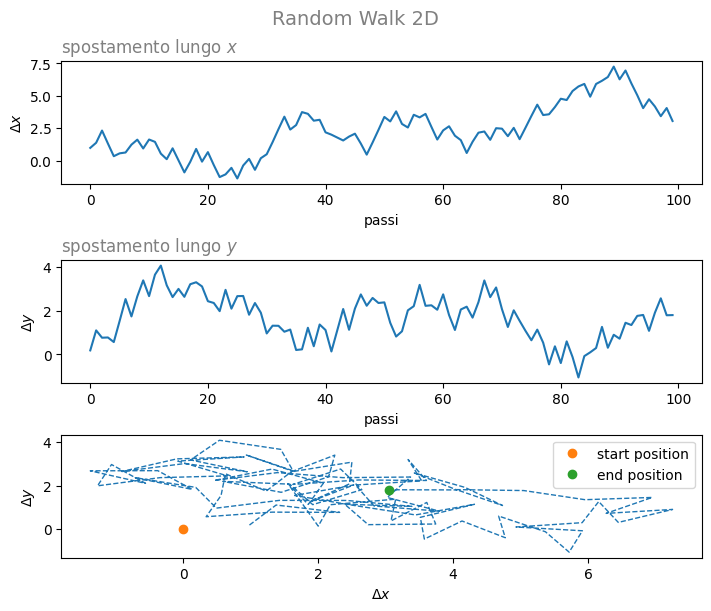

In [13]:
n_passi= 100
xx=np.arange(0,n_passi,1)
passo=1
pstart=np.array([0,0])
rw1=walk_2d(pstart,passo, n_passi)

fig1, ax1=plt.subplots(3,1, figsize=(7,6), layout='constrained')
#fig.subplots_adjust(hspace=0)
fig1.suptitle('Random Walk 2D', color='grey', fontsize=14)

ax1[0].plot(xx, rw1[0])
ax1[0].set_xlabel('passi')
ax1[0].set_ylabel(r'$\Delta x$')
#ax1[0].set_ylim(-25,25)
ax1[0].set_title(r'spostamento lungo $x$', loc='left', color='grey', fontsize=12)

ax1[1].plot(xx, rw1[1])
ax1[1].set_xlabel('passi')
ax1[1].set_ylabel(r'$\Delta y$')
#ax1[1].set_ylim(-25,25)
ax1[1].set_title(r'spostamento lungo $y$',  loc='left', color='grey', fontsize=12)

ax1[2].plot(rw1[0], rw1[1], linewidth=1, linestyle='--')
ax1[2].plot(pstart[0], pstart[1], 'o', markersize=6, label='start position')
ax1[2].plot(rw1[0][-1], rw1[1][-1], 'o', markersize=6, label='end position')
ax1[2].set_xlabel(r'$\Delta x$')
ax1[2].set_ylabel(r'$\Delta y$')
ax1[2].legend()
#ax1[2].set_ylim(-25,25)

# Allineo SOLO gli assi X del primo e secondo plot
fig1.align_xlabels([ax1[0], ax1[1]])

In [4]:
## Random Walk Animation
'''
%matplotlib widget
fig1, ax=plt.subplots()

artists=[]
ax.set_xlabel(r'$\Delta x$')
ax.set_ylabel(r'$\Delta y$')
for i in range(rw1.shape[1]):
    motion= ax.scatter(rw1[0][i], rw1[1][i], c='b')
    artists.append(motion)

ani= animation.ArtistAinimation(fig=fig1, artists=artists, interval=200)
plt.show()
'''

"\n%matplotlib widget\nfig1, ax=plt.subplots()\n\nartists=[]\nax.set_xlabel(r'$\\Delta x$')\nax.set_ylabel(r'$\\Delta y$')\nfor i in range(rw1.shape[1]):\n    motion= ax.scatter(rw1[0][i], rw1[1][i], c='b')\n    artists.append(motion)\n\nani= animation.ArtistAinimation(fig=fig1, artists=artists, interval=200)\nplt.show()\n"

### produrre un grafico 2D delle posizioni di 5 random walker per 1000 passi

In [14]:
def rnd_ws(start, step, n,nwr):
    '''
    rnd_ws(start, step,n,nrw): funzione che simula il moto 2D di un certo numero di random walkers
    start : vettore posizione iniziale
    step  : passo random walk
    nwr   : numero di random walkers
    n     : numero di passi

    return rws: array di random walks,in cui ciascun elemento contiene lo spostamento lungo x e y 
    '''
    t=np.full(n,0)
    rws=np.array([np.array([t,t]) for x in range(nwr)])
    for i in range(nwr):
        rw= walk_2d(start,step, n)
        rws[i,0]=rw[0]
        rws[i,1]=rw[1]
    return rws

In [30]:
n1=1000
nrw1=5
rw_5=rnd_ws(pstart, passo, n1, nrw1)
#print(rw_5)

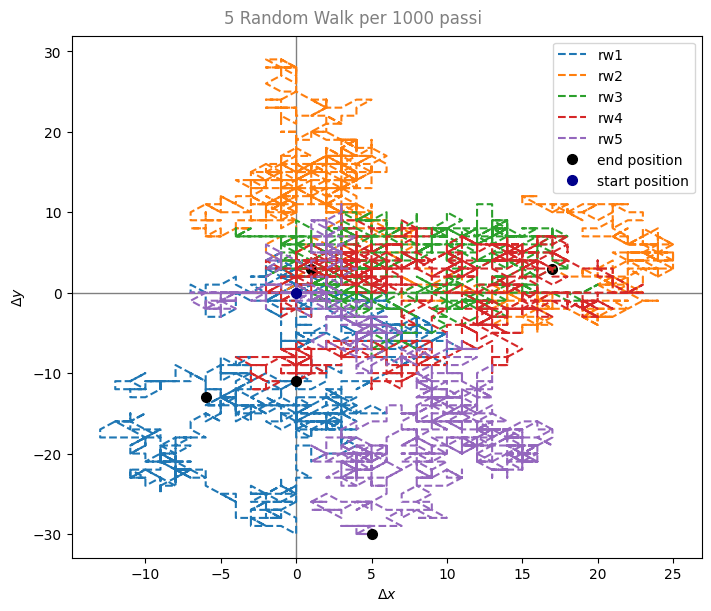

In [25]:
fig2, ax2=plt.subplots(figsize=(7,6), layout='constrained')

plt.suptitle('5 Random Walk per 1000 passi ', color = 'grey')
count=1
mark=''
ax2.axhline(0, color='grey', linewidth=1)
ax2.axvline(0, color='grey', linewidth=1)
for i in rw_5:
    if(count==5):
        mark='end position'
    ax2.plot(i[0], i[1], '--', label='rw{:d}'.format(count))
    ax2.plot(i[0][-1], i[1][-1],'o', markersize=7,label=mark, color='black')
    count +=1
ax2.plot(pstart[0], pstart[1], 'o', markersize=7, label='start position', color='darkblue')
ax2.set_xlabel(r'$\Delta x$')
ax2.set_ylabel(r'$\Delta y$')
ax2.legend()

### produrre un grafico con due pannelli che mosti:
- nel primo pannello lo stesso grafico del punto A
- nel secondo pannello il quadrato della distanza dal punto di partenza in funzione dei passi per gli stessi 5 random walker.

In [26]:
def euclid_d(p1,p2):
    '''
    euclid_d(p1, p2): funzione calcola il quadrato della distanza euclidea tra 2 punti del piano
    p1  : array contenente le coordinate della posizione iniziale rispetto alla quale calcolare la distanza
    p2  : array contenente le coordinate dei punti per i quali si vuole calcolare la distanza rispetto a p1

    return de: array contenente la distanza di ciascun punto di p2 da p1 
    '''
    t=np.full(n1,0)
    de=np.array([t for x in range(5)])
    for i,j in zip(p2, range(5)):
        sum=0
        d=(i[0]-p1[0])**2 + (i[1]-p1[1])**2
        sum=sum+d
        de[j]=sum
    return de

d_rw5=euclid_d(pstart, rw_5)
print(d_rw5)

[[  0   0   0 ... 169 180 205]
 [  0   1   1 ... 365 328 298]
 [  0   0   1 ...  10  16  10]
 [  0   0   0 ... 101 100 121]
 [  0   1   1 ... 857 916 925]]


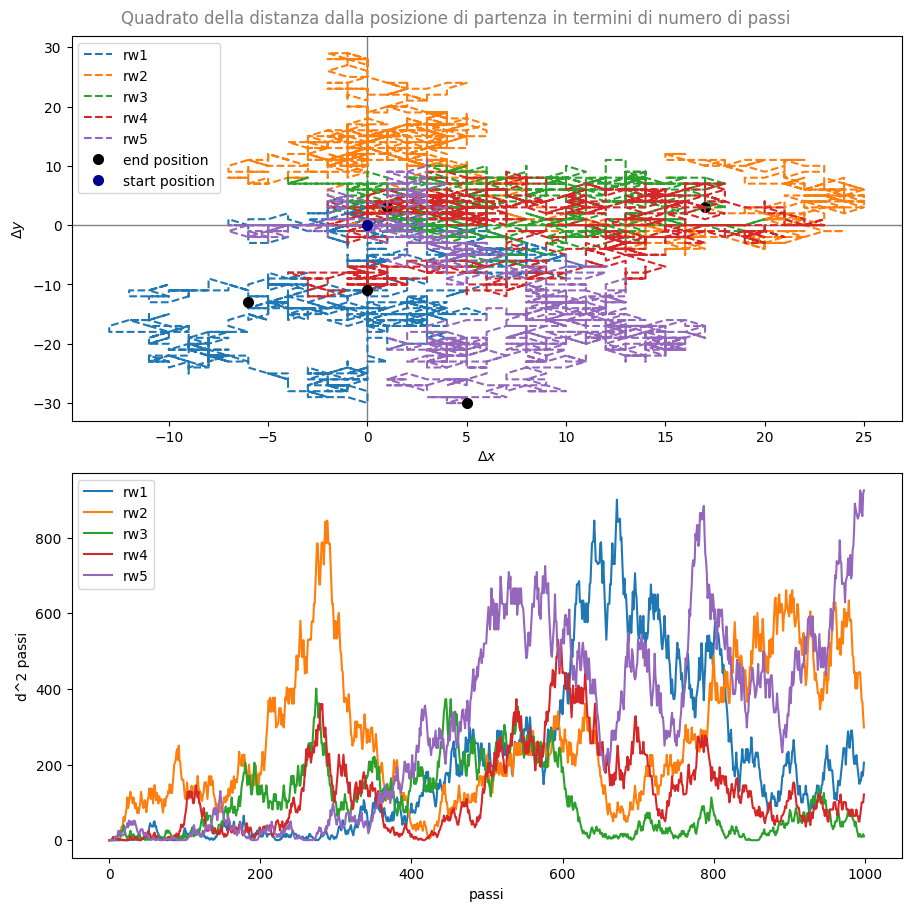

In [27]:
xx1=np.arange(0, n1, 1)
xxl=np.array([xx1 for x in range(5)])
fig4, ax=plt.subplots(2,1, figsize=(9,9), layout='constrained')
#fig.subplots_adjust(hspace=0)

plt.suptitle('Quadrato della distanza dalla posizione di partenza in termini di numero di passi', color='grey')
count=1
mark=''
ax[0].axhline(0, color='grey', linewidth=1)
ax[0].axvline(0, color='grey', linewidth=1)
for i in rw_5:
    if(count==5):
        mark='end position'
    ax[0].plot(i[0], i[1], '--', label='rw{:d}'.format(count))
    ax[0].plot(i[0][-1], i[1][-1],'o', markersize=7,label=mark, color='black')
    count +=1
ax[0].plot(pstart[0], pstart[1], 'o', markersize=7, label='start position', color='darkblue')
ax[0].set_xlabel(r'$\Delta x$')
ax[0].set_ylabel(r'$\Delta y$')
ax[0].legend()

count=1
for l,z in zip(xxl,d_rw5):
    ax[1].plot(l, z, '-', label='rw{:d}'.format(count))
    ax[1].set_ylabel(r'd^2 passi')
    ax[1].set_xlabel('passi')
    count+=1
ax[1].legend()

plt.show()

### produrre un grafico 2D della posizione di 100 random walker dopo 10, 100 e 1000 passi

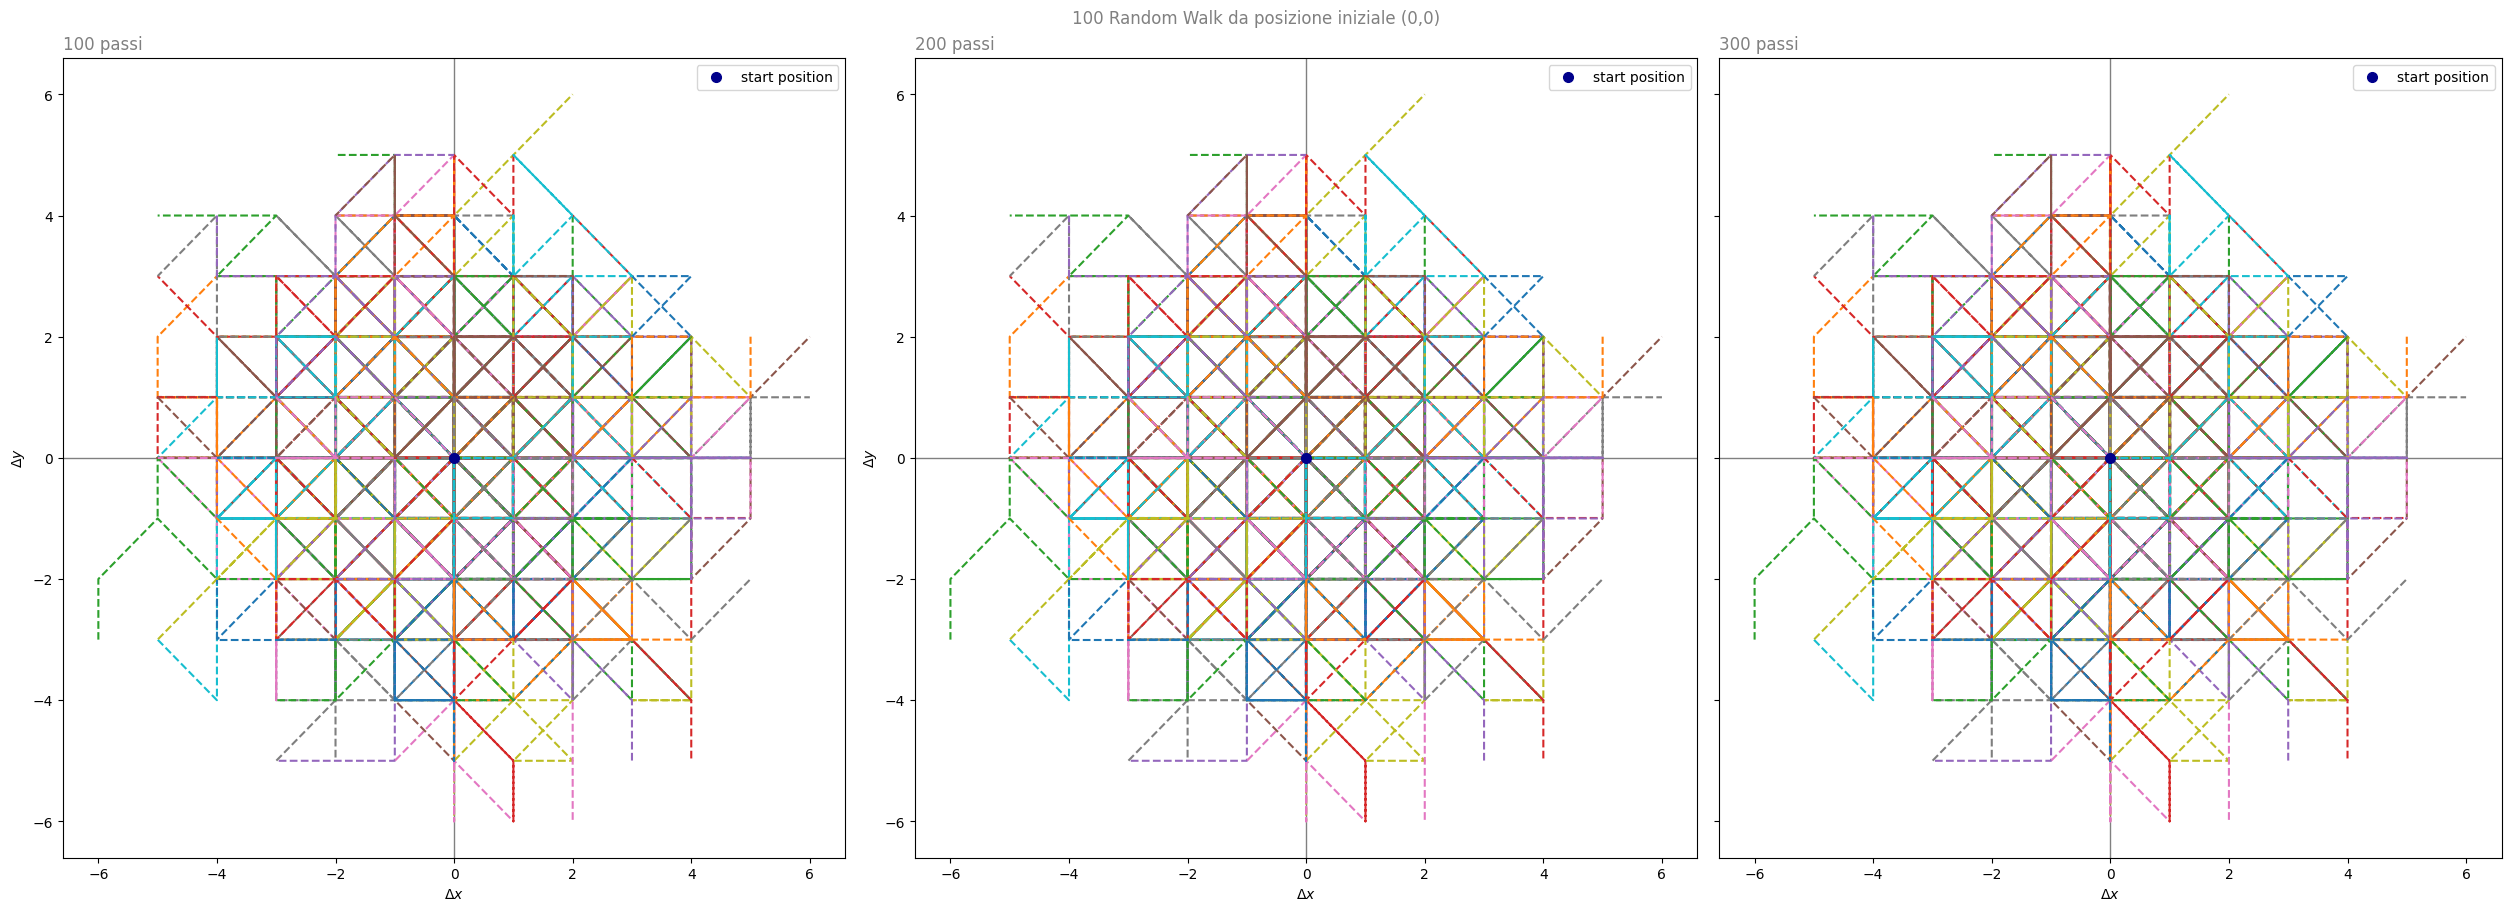

In [31]:
#n passi = 100
rw_10=rnd_ws(pstart,passo,10, n1)
rw_100=rnd_ws(pstart,passo,100, n1)
rw_1000=rnd_ws(pstart,passo,1000, n1)
rw_l100=[rw_10,rw_100,rw_1000]
p=100
fig5, (ax1, ax2, ax3)=plt.subplots(1,3, figsize=(25,9), layout='constrained')

plt.suptitle('100 Random Walk da posizione iniziale (0,0)', color = 'grey')
count1=1
for ax in fig5.get_axes():
    count=0
    ax.axhline(0, color='grey', linewidth=1)
    ax.axvline(0, color='grey', linewidth=1)

    for i in rw_l100[count]:
        ax.plot(i[0], i[1], '--')
    count +=1
    ax.set_title('{:d} passi'.format(count1*p), loc='left', color='grey')
    ax.plot(pstart[0], pstart[1], 'o', markersize=7, label='start position', color='darkblue')
    ax.set_xlabel(r'$\Delta x$')
    ax.set_ylabel(r'$\Delta y$')
    ax.legend()
    count1+=1
    
ax.label_outer()
